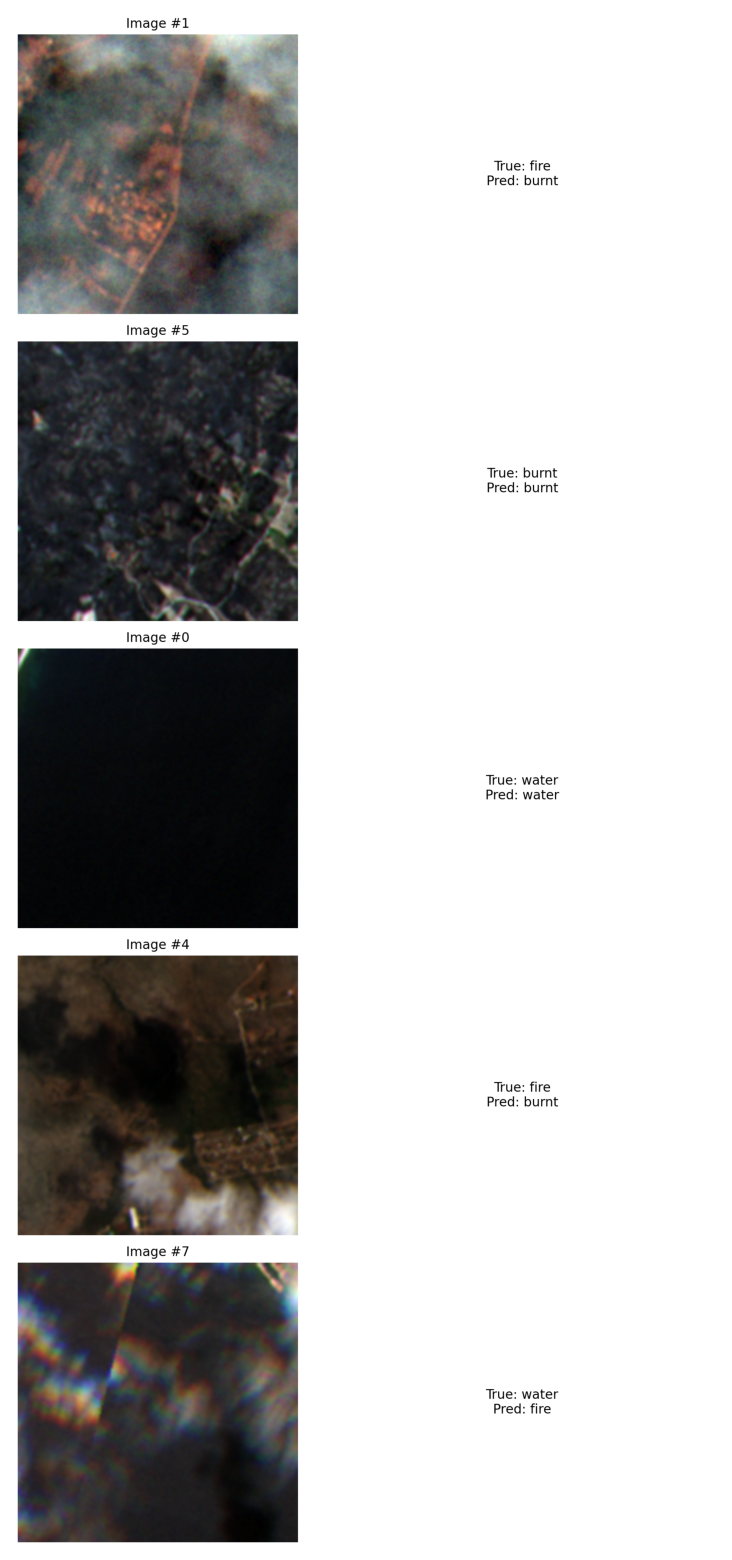

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/Data/phi2FM_n_shot/finetuning/phisatnet_downstream/fire/fire/20250805_PhiSatNetDownstream_frozen_50/val_images/val_40.png")
#img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/burned_area/burned_area/20250607_CoreEncoderGeoPretrained_mh_pred_frozen_1.0/val_images/val_0.png")
plt.figure(figsize=(20,20))
plt.imshow(img)
plt.axis("off")   # turn off axes if you like
plt.show()

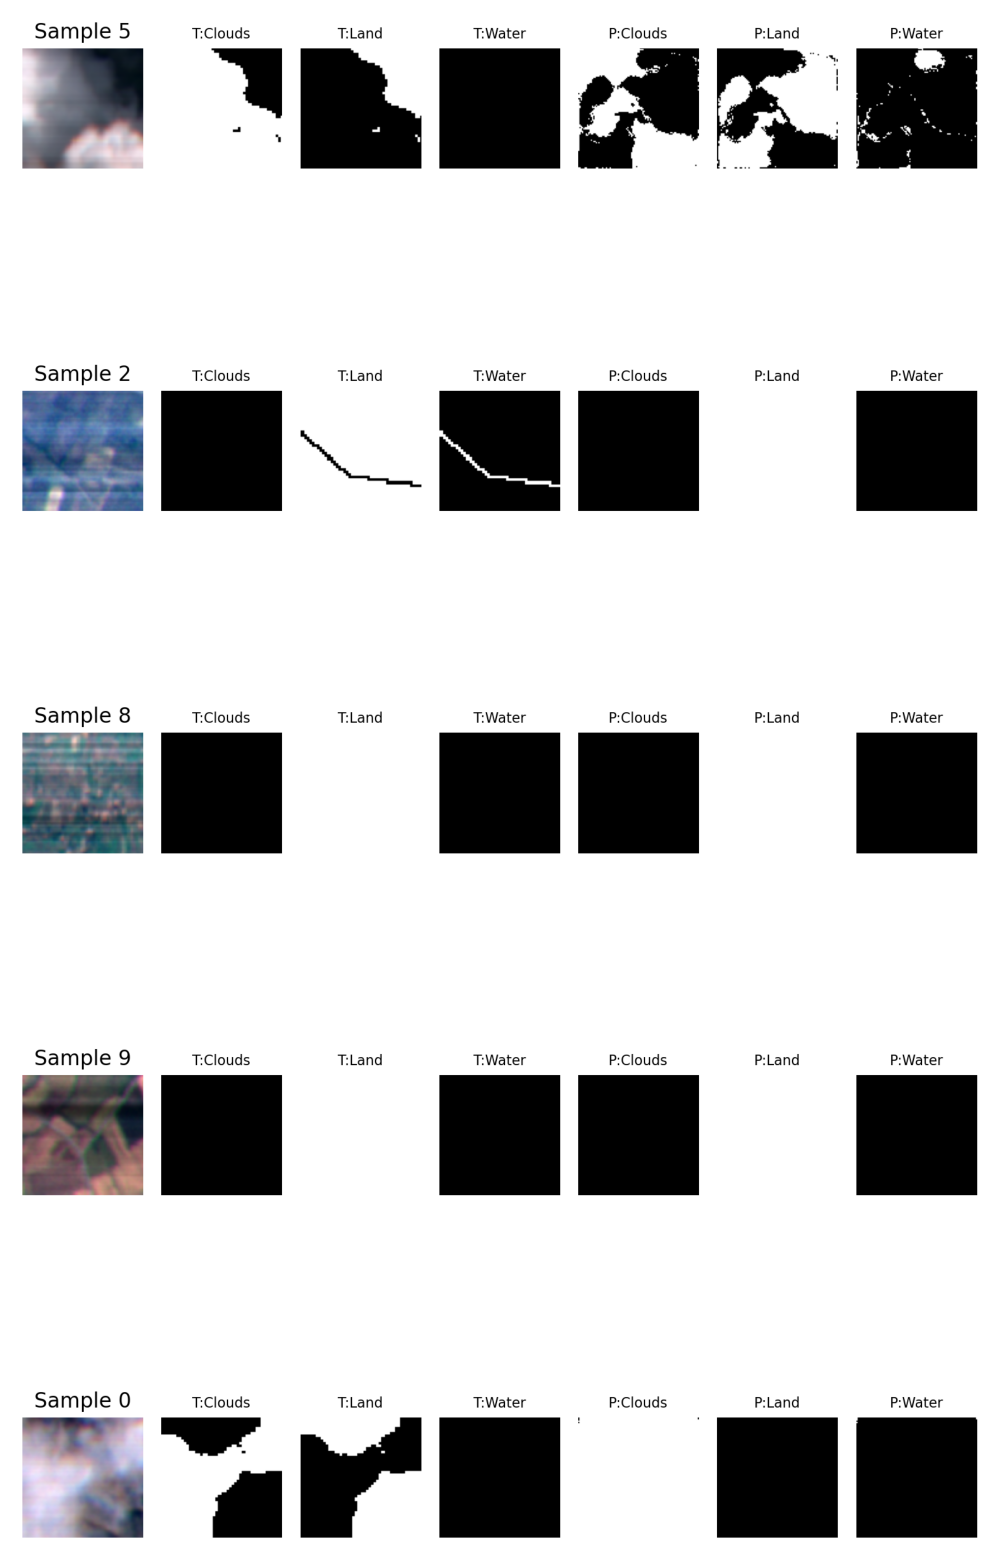

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/Data/phi2FM_n_shot/finetuning/phi2_SatMAE/worldfloods/worldfloods/20250811_SatMAE_frozen_500/val_images/val_90.png")
#img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/burned_area/burned_area/20250607_CoreEncoderGeoPretrained_mh_pred_frozen_1.0/val_images/val_0.png")
plt.figure(figsize=(20,20))
plt.imshow(img)
plt.axis("off")   # turn off axes if you like
plt.show()

In [8]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Open the fire dataset
zarr_path = "/Data/fire_dataset/fire_dataset.zarr"
root = zarr.open(zarr_path, mode='r')

print("Dataset structure:")
print(f"Available sets: {list(root.keys())}")

samples = [
  "0000079",
  "0000867",
  "0001484",
  "0000593",
  "0000539",
  "0001420",
  "0001478",
  "0000981",
  "0001536",
  "0000419",
  "0001551",
  "0001171",
  "0001502",
  "0000986",
  "0000668",
  "0000930",
  "0000992",
  "0001313",
  "0000327",
  "0001631",
  "0003238",
  "0003127",
  "0002630",
  "0002423",
  "0002259",
  "0003142",
  "0002643",
  "0002900",
  "0002825",
  "0002772",
  "0003090",
  "0003363",
  "0002819",
  "0003144",
  "0002376",
  "0003337",
  "0003301",
  "0002442",
  "0002191",
  "0002830",
  "0004055",
  "0003407",
  "0004103",
  "0003615",
  "0004040",
  "0003861",
  "0004144",
  "0003848",
  "0004133",
  "0004149"
]
# Focus on the test set
if 'trainval' in root:
    test_set = root['trainval']
    print(f"\nTest set samples: {len(test_set.keys())}")
    
    # Collect all labels and find samples with label 0
    all_labels = []
    samples_with_label_0 = []
    
    for sample_id in sorted(samples):#test_set.keys()):
        sample = test_set[sample_id]
        
        # Get the label
        if 'label' in sample:
            label_zarr = sample['label']
            
            # Handle different label formats (scalar, array, etc.)
            if label_zarr.shape == ():  # 0-dimensional (scalar)
                label_data = label_zarr[()]  # Use [()] for 0-d arrays
                label_value = int(label_data)
            else:  # Multi-dimensional
                label_data = label_zarr[:]
                if label_data.ndim == 1 and len(label_data) == 1:  # single element array
                    label_value = int(label_data[0])
                else:  # for arrays, get the most common value
                    unique_vals, counts = np.unique(label_data, return_counts=True)
                    label_value = int(unique_vals[np.argmax(counts)])
            
            all_labels.append(label_value)
            
            if label_value == 1:
                samples_with_label_0.append(sample_id)
                print(f"Found sample with label 0: {sample_id}")
    
    # Print summary statistics
    label_counts = Counter(all_labels)
    print(f"\nLabel distribution in test set:")
    for label, count in sorted(label_counts.items()):
        print(f"Label {label}: {count} samples ({count/len(all_labels)*100:.1f}%)")
    
    print(f"\nTotal samples with label 0: {len(samples_with_label_0)}")
    if samples_with_label_0:
        print(f"Sample IDs with label 0: {samples_with_label_0[:10]}...")  # Show first 10
else:
    print("Test set not found in the dataset")

Dataset structure:
Available sets: ['test', 'trainval']

Test set samples: 4239
Found sample with label 0: 0000327
Found sample with label 0: 0000419
Found sample with label 0: 0000539
Found sample with label 0: 0000593
Found sample with label 0: 0000668
Found sample with label 0: 0000867
Found sample with label 0: 0000930
Found sample with label 0: 0000981
Found sample with label 0: 0000986
Found sample with label 0: 0000992
Found sample with label 0: 0001171
Found sample with label 0: 0001313
Found sample with label 0: 0001420
Found sample with label 0: 0001478
Found sample with label 0: 0001484
Found sample with label 0: 0001502
Found sample with label 0: 0001536
Found sample with label 0: 0001551
Found sample with label 0: 0001631

Label distribution in test set:
Label 0: 1 samples (2.0%)
Label 1: 19 samples (38.0%)
Label 2: 20 samples (40.0%)
Label 3: 10 samples (20.0%)

Total samples with label 0: 19
Sample IDs with label 0: ['0000327', '0000419', '0000539', '0000593', '0000668',

In [ ]:
# Visualize some samples with label 0 if they exist
if samples_with_label_0:
    print(f"Visualizing first few samples with label 0...")
    
    # Show up to 6 samples
    n_samples_to_show = min(6, len(samples_with_label_0))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, sample_id in enumerate(samples_with_label_0[:n_samples_to_show]):
        sample = test_set[sample_id]
        
        # Get image data
        if 'img' in sample:
            img_data = sample['img'][:]
            
            # Handle different image formats
            if img_data.ndim == 3:
                # If channels first (C, H, W), transpose to (H, W, C)
                if img_data.shape[0] < img_data.shape[-1]:
                    img_data = np.transpose(img_data, (1, 2, 0))
                
                # If RGB, use first 3 channels
                if img_data.shape[-1] >= 3:
                    img_display = img_data[:, :, :3]
                else:
                    img_display = img_data[:, :, 0]  # Grayscale
            elif img_data.ndim == 2:
                img_display = img_data
            else:
                print(f"Unexpected image shape for sample {sample_id}: {img_data.shape}")
                continue
            
            # Normalize for display
            if img_display.dtype in [np.float32, np.float64]:
                # If values are in [0,1] range
                if img_display.max() <= 1.0:
                    img_display = (img_display * 255).astype(np.uint8)
                # If values are larger, normalize
                elif img_display.max() > 255:
                    img_display = ((img_display - img_display.min()) / 
                                  (img_display.max() - img_display.min()) * 255).astype(np.uint8)
            
            axes[i].imshow(img_display, cmap='gray' if len(img_display.shape) == 2 else None)
            axes[i].set_title(f'Sample {sample_id}\nLabel: 0')
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f'No image data\nfor sample {sample_id}', 
                        ha='center', va='center')
            axes[i].set_title(f'Sample {sample_id}')
    
    # Hide unused subplots
    for i in range(n_samples_to_show, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed info about first sample with label 0
    first_sample_id = samples_with_label_0[0]
    first_sample = test_set[first_sample_id]
    print(f"\nDetailed info for sample {first_sample_id}:")
    print(f"Available keys: {list(first_sample.keys())}")
    
    if 'img' in first_sample:
        print(f"Image shape: {first_sample['img'].shape}")
        print(f"Image dtype: {first_sample['img'].dtype}")
    
    if 'label' in first_sample:
        label_data = first_sample['label'][:]
        print(f"Label shape: {label_data.shape}")
        print(f"Label dtype: {label_data.dtype}")
        print(f"Label values: {label_data}")
    
    # Check attributes
    print(f"Sample attributes: {dict(first_sample.attrs)}")
    
else:
    print("No samples with label 0 found in the test set.")

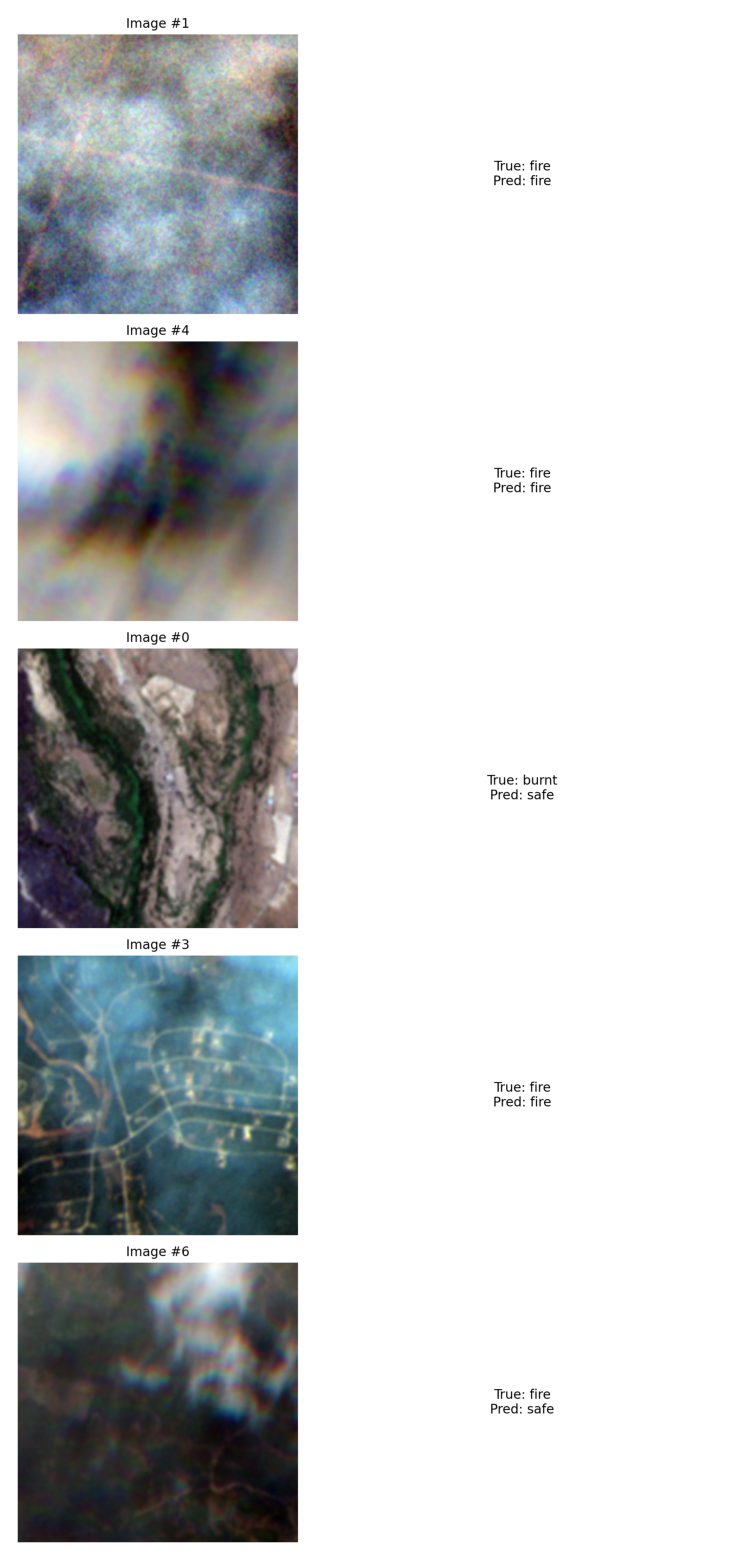

In [41]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/fire/fire/20250607_CoreEncoderGeoPretrained_Classifier_mh_pred_frozen_1.0/val_images/val_30.png")
#img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/burned_area/burned_area/20250607_CoreEncoderGeoPretrained_mh_pred_frozen_1.0/val_images/val_0.png")
plt.figure(figsize=(20,20))
plt.imshow(img)
plt.axis("off")   # turn off axes if you like
plt.show()

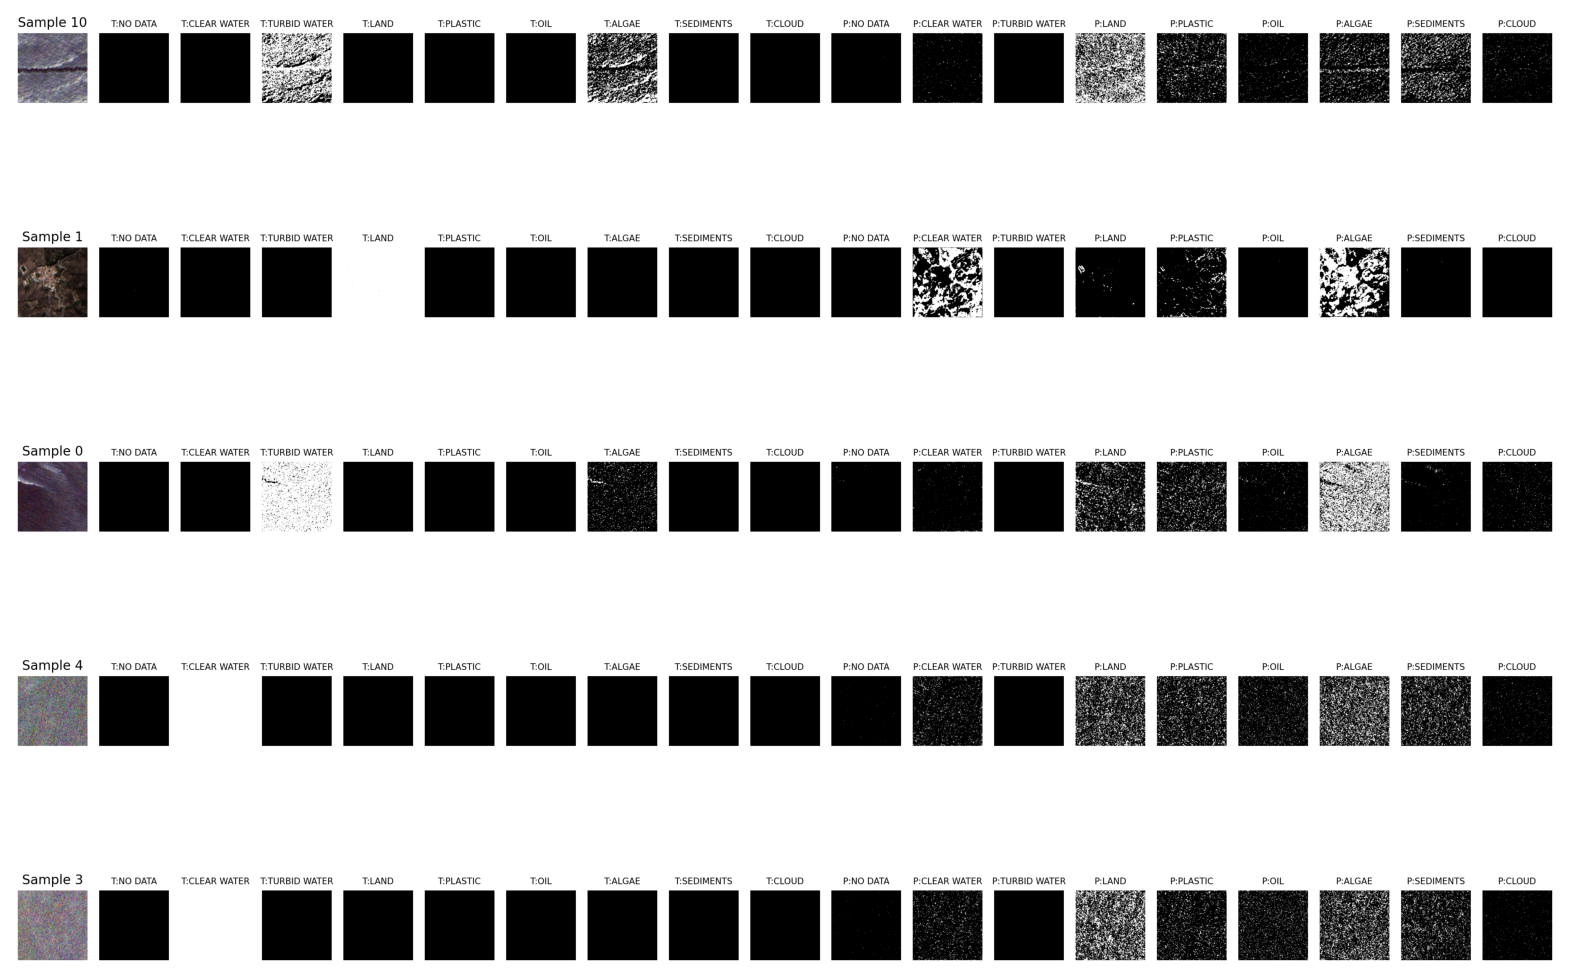

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/Data/phi2FM_n_shot/finetuning/phi2_GeoAware/anomaly_detection/anomaly_detection/20250908_CoreEncoderGeoPretrained_mh_pred_frozen_50/val_images/val_0.png")
#img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/burned_area/burned_area/20250607_CoreEncoderGeoPretrained_mh_pred_frozen_1.0/val_images/val_0.png")
plt.figure(figsize=(20,20))
plt.imshow(img)
plt.axis("off")   # turn off axes if you like
plt.show()

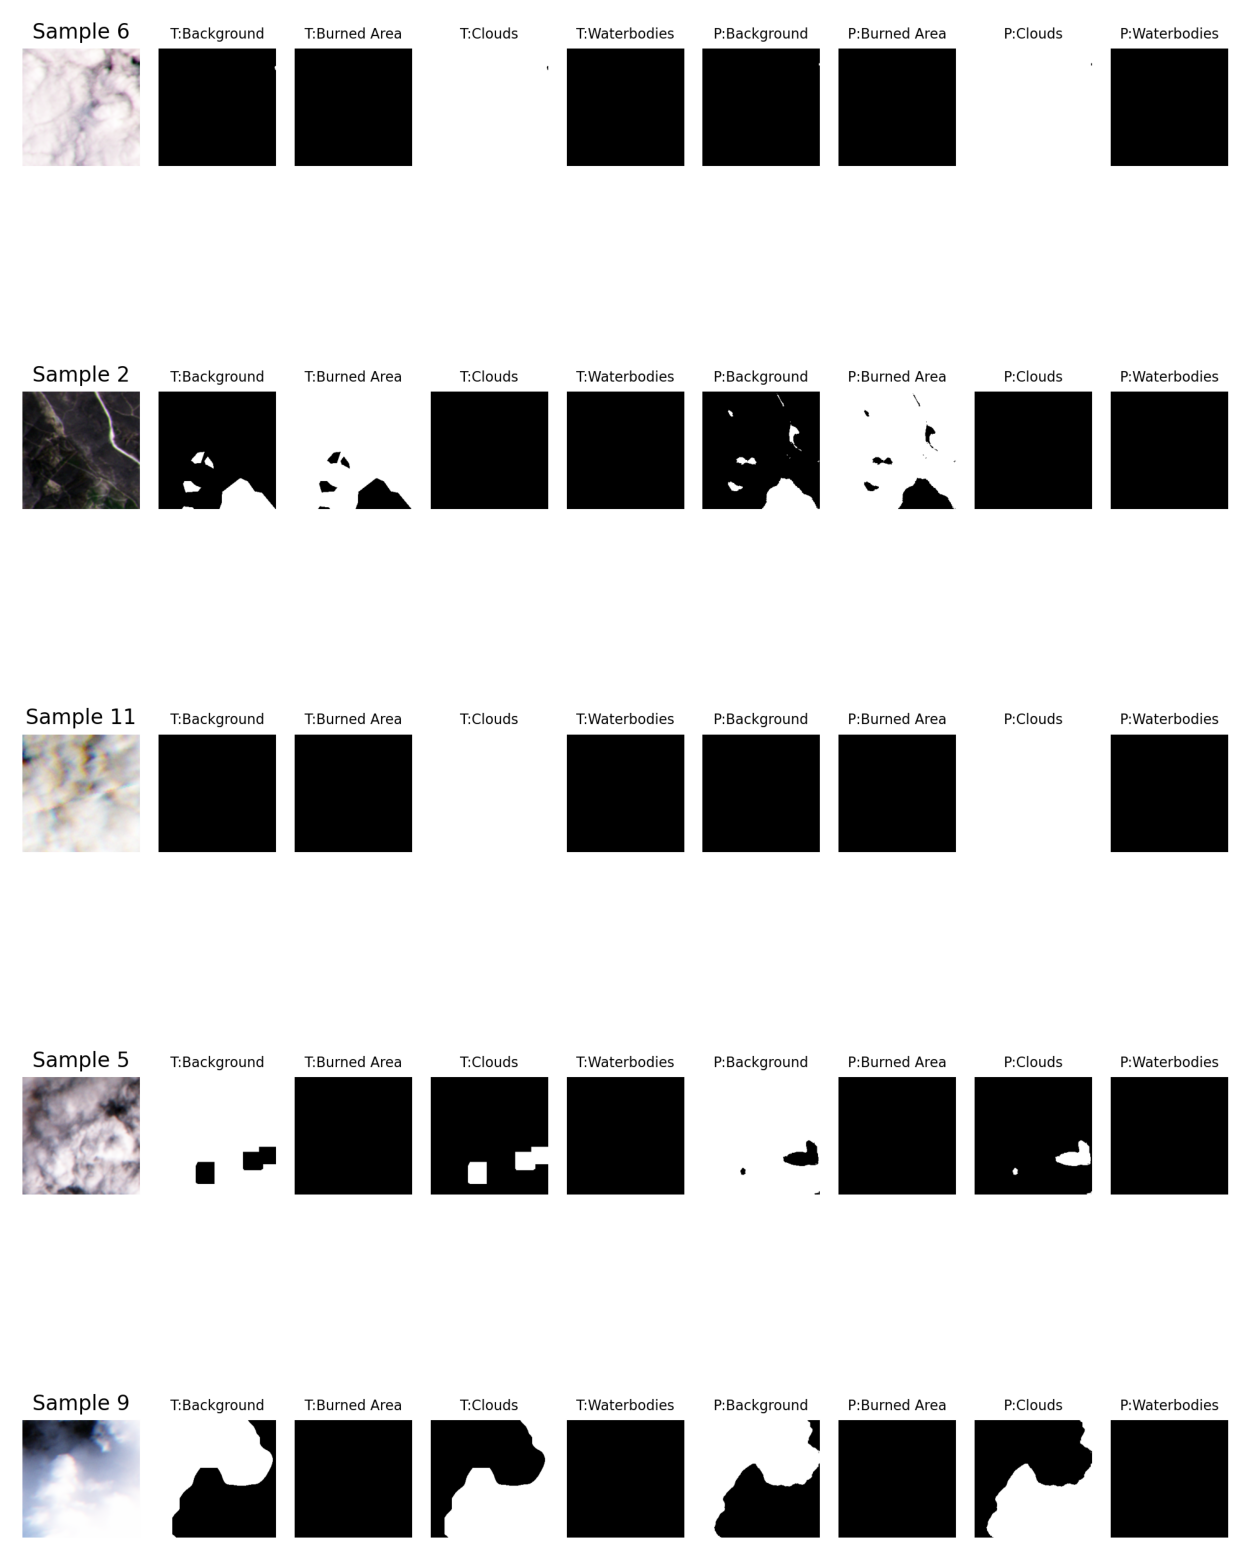

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/burned_area/burned_area/20250611_CoreEncoderGeoPretrained_mh_pred_frozen_1.0/val_images/val_60.png")
#img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/burned_area/burned_area/20250607_CoreEncoderGeoPretrained_mh_pred_frozen_1.0/val_images/val_0.png")
plt.figure(figsize=(20,20))
plt.imshow(img)
plt.axis("off")   # turn off axes if you like
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/burned_area/burned_area/20250611_CoreEncoderGeoPretrained_mh_pred_frozen_1.0/val_images/val_40.png")
#img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/burned_area/burned_area/20250607_CoreEncoderGeoPretrained_mh_pred_frozen_1.0/val_images/val_0.png")
plt.figure(figsize=(20,20))
plt.imshow(img)
plt.axis("off")   # turn off axes if you like
plt.show()

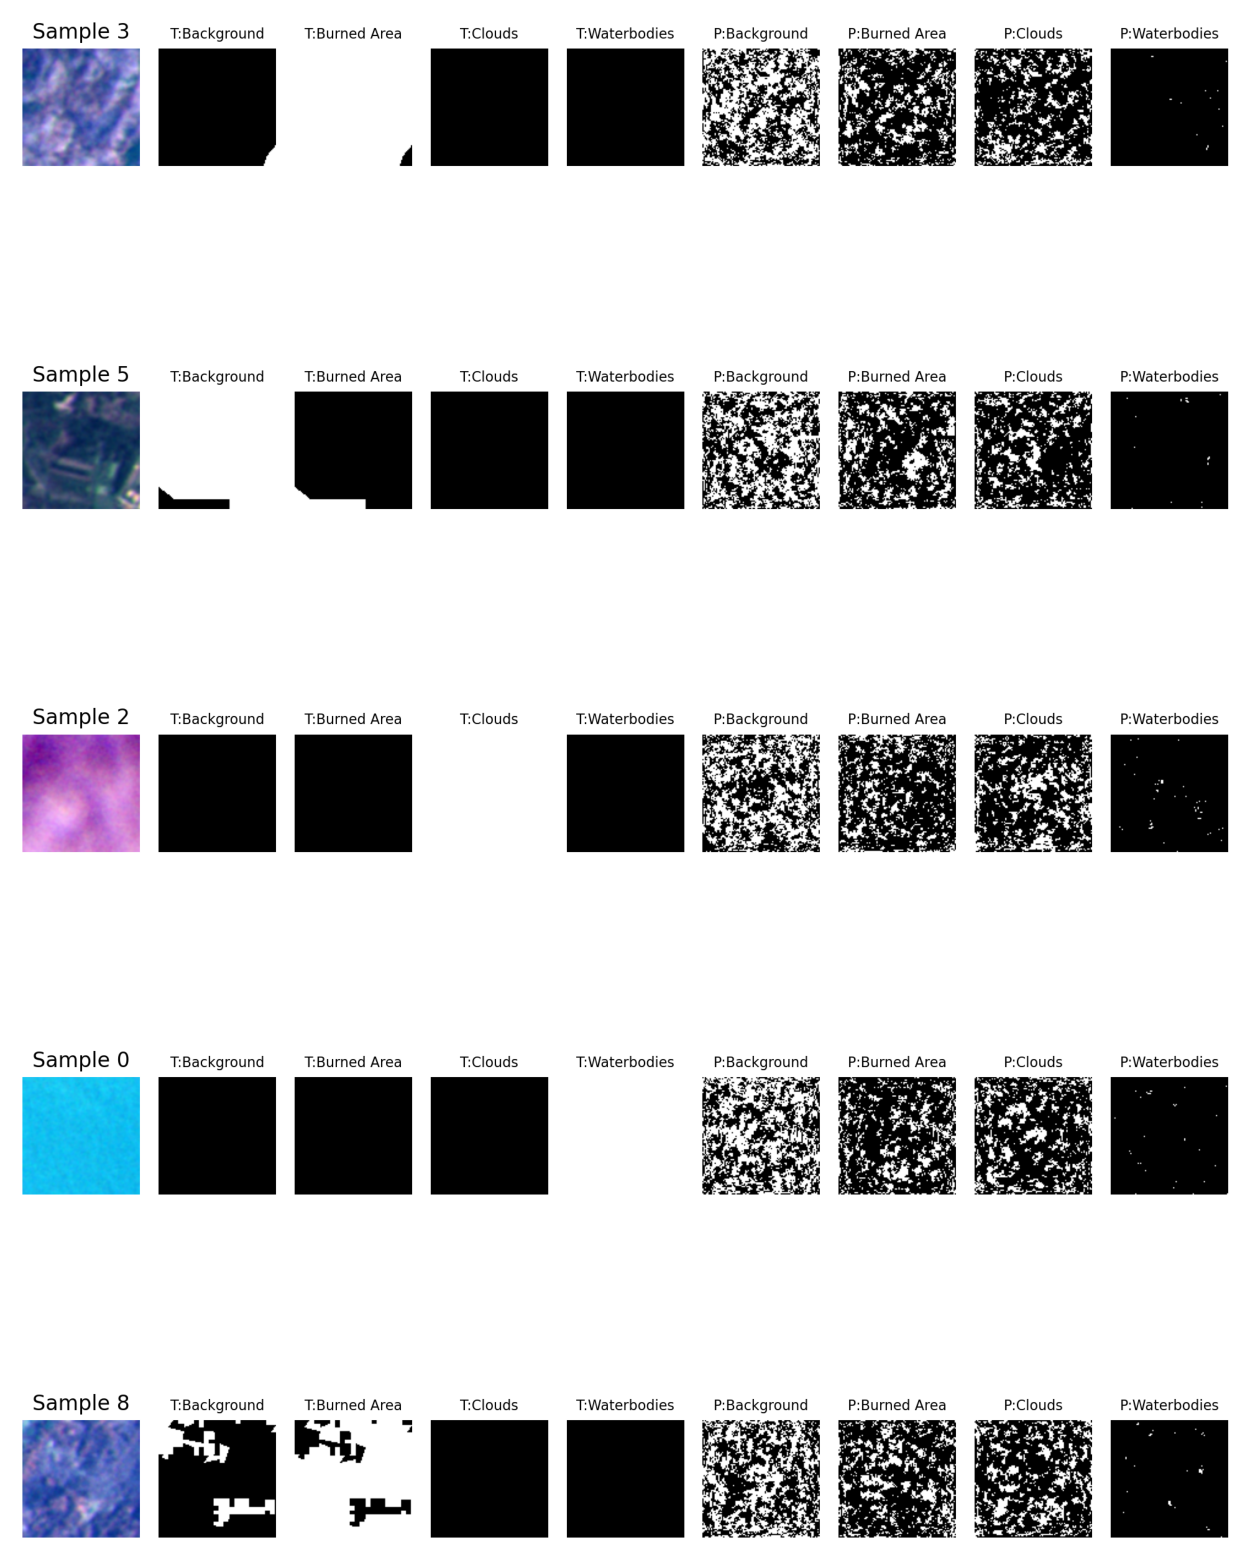

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_SatMAE/burned_area/burned_area/20250615_SatMAE_frozen_1.0/val_images/val_2.png")
#img = mpimg.imread("/Data/phi2FM_models/finetuning/phi2_GeoAware/burned_area/burned_area/20250607_CoreEncoderGeoPretrained_mh_pred_frozen_1.0/val_images/val_0.png")
plt.figure(figsize=(20,20))
plt.imshow(img)
plt.axis("off")   # turn off axes if you like
plt.show()

In [2]:

from terratorch.registry import BACKBONE_REGISTRY
from terratorch.models.encoder_decoder_factory import EncoderDecoderFactory, _get_decoder_and_head_kwargs
decoder_name: str = "UNetDecoder"
decoder_channels: list = [512, 256, 128, 64]
decoder_kwargs: dict = None
num_classes: int = 4
_get_decoder_and_head_kwargs(
            decoder_name,
            decoder_channels,
            {'channels': [512, 256, 128, 64]},
            {},
            num_classes,
        )

(UNetDecoder(
   (decoder): UnetDecoder(
     (center): Identity()
     (blocks): ModuleList(
       (0): DecoderBlock(
         (conv1): Conv2dReLU(
           (0): Conv2d(192, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
           (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU(inplace=True)
         )
         (attention1): Attention(
           (attention): Identity()
         )
         (conv2): Conv2dReLU(
           (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
           (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU(inplace=True)
         )
         (attention2): Attention(
           (attention): Identity()
         )
       )
       (1): DecoderBlock(
         (conv1): Conv2dReLU(
           (0): Conv2d(768, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
           (1): Batch

In [2]:
from terratorch.registry import BACKBONE_REGISTRY

BACKBONE_REGISTRY

/Data/gdaga/anaconda3/envs/esa-phisatnet/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MultiSourceRegistry(terratorch=Registry({'prithvi_eo_tiny': <function prithvi_eo_tiny at 0x737e78b05760>, 'prithvi_eo_v1_100': <function prithvi_eo_v1_100 at 0x737e78b05800>, 'prithvi_eo_v2_300': <function prithvi_eo_v2_300 at 0x737e78b058a0>, 'prithvi_eo_v2_600': <function prithvi_eo_v2_600 at 0x737e78b05940>, 'prithvi_eo_v2_300_tl': <function prithvi_eo_v2_300_tl at 0x737e78b059e0>, 'prithvi_eo_v2_600_tl': <function prithvi_eo_v2_600_tl at 0x737e78b05a80>, 'dofa_small_patch16_224': <function dofa_small_patch16_224 at 0x737e78b18fe0>, 'dofa_base_patch16_224': <function dofa_base_patch16_224 at 0x737e78b19080>, 'dofa_large_patch16_224': <function dofa_large_patch16_224 at 0x737e78b19120>, 'dofa_huge_patch16_224': <function dofa_huge_patch16_224 at 0x737e78b191c0>, 'satlas_swin_t_sentinel2_mi_ms': <function satlas_swin_t_sentinel2_mi_ms at 0x737e78b196c0>, 'satlas_swin_t_sentinel2_mi_rgb': <function satlas_swin_t_sentinel2_mi_rgb at 0x737e78b19760>, 'satlas_swin_t_sentinel2_si_ms': <fun

In [3]:

from terratorch.registry import BACKBONE_REGISTRY
from terratorch.models.encoder_decoder_factory import EncoderDecoderFactory, _get_decoder_and_head_kwargs
import torch.nn as nn

def get_module_size(module: nn.Module) -> float:
    """
    Returns the memory size of all parameters in a given module
    """
    total_params = 0
    for param in module.parameters():
        total_params += param.numel() #* param.element_size()
    return total_params / (1000 ** 2)  # Milions

model = EncoderDecoderFactory().build_model(
    task="segmentation",
    backbone="terramind_v1_base",
    backbone_modalities=["S2L1C"],
    decoder="UNetDecoder",
    decoder_channels=[512, 256, 128, 64],
    backbone_pretrained=True,
    num_classes=4,
    necks=[{
        "name": "SelectIndices",
        "indices": [2, 5, 8, 11]
    },
        {"name": "ReshapeTokensToImage",
            "remove_cls_token": False},
        {"name": "LearnedInterpolateToPyramidal"}]
)
model


PixelWiseModel(
  (encoder): TerraMindViT(
    (encoder_embeddings): ModuleDict(
      (untok_sen2l1c@224): ImageEncoderEmbedding(
        (proj): Linear(in_features=3328, out_features=768, bias=False)
      )
    )
    (encoder): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm()
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=False)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=False)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm()
        (mlp): GatedMlp(
          (fc1): Linear(in_features=768, out_features=2048, bias=False)
          (act): SiLU()
          (fc2): Linear(in_features=2048, out_features=768, bias=False)
          (fc3): Linear(in_features=768, out_features=2048, bias=False)
        )
      )
    )
    (encoder_norm): LayerNorm()
  )
  (decoder): UNetDecoder(
   

In [4]:
decoder_name: str = "UNetDecoder"
decoder_channels: list = [1000, 500, 250, 125]
decoder_kwargs: dict = None
num_classes: int = 4
decoder = _get_decoder_and_head_kwargs(
            decoder_name,
            decoder_channels,
            {'channels': [512, 256, 128, 64]},
            {},
            num_classes,
        )
decoder[1]
#get_module_size(decoder[0])
# decoder = UnetDecoder(
#     encoder_channels=[in_channels],  # Only the main feature, no skips
#     decoder_channels=[...],          # Your desired decoder channel sizes
#     n_blocks=len(decoder_channels),
#     use_batchnorm=True,
#     attention_type=None,
#     center=False,
# )

# # Forward pass with only the main feature
# output = decoder(x)
# decoder

{'num_classes': 4}

In [ ]:
get_module_size(model.decoder)

UNetDecoder(
  (decoder): UnetDecoder(
    (center): Identity()
    (blocks): ModuleList(
      (0): DecoderBlock(
        (conv1): Conv2dReLU(
          (0): Conv2d(1536, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (attention1): Attention(
          (attention): Identity()
        )
        (conv2): Conv2dReLU(
          (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (attention2): Attention(
          (attention): Identity()
        )
      )
      (1): DecoderBlock(
        (conv1): Conv2dReLU(
          (0): Conv2d(896, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(256, eps=1e-05, mo

In [7]:
get_module_size(model.decoder)

12.869376